File to view plots and mess around with interesting results without having to run code I don't care about for this purpose.


In [47]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Get the directory where you are currently working
current_path = os.getcwd()

# Join it with '..' to go up one level to the main folder
parent_path = os.path.abspath(os.path.join(current_path, '..'))

# Add it to sys.path
if parent_path not in sys.path:
    sys.path.insert(0, parent_path)

import numpy as np
import scipy as sp
from conversions import cm_to_m, erg_to_joule
from rr_escape import get_rr_escape_diagnostics, examine_atmosphere_for_rr_escape
from atmospheres.atmosphere_setting import Atmosphere
from bulk_param_examination import make_simple_atmosphere, sweep_masses, sweep_fluxes
import matplotlib.pyplot as plt






The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
'''
#I didnt want to get rid of this because I may want to make some simple plots with this later.

### Want to examine how planetary mass affects mass loss rate ###
M_earth = 5.9722 * 10**24               #[kg]        mass of the earth
Mass_array = np.linspace(0.5, 30, 100, endpoint=True) * M_earth #[kg] array of planetary masses from 1 to 30 times the mass of the earth

atmospheres_H2_varied_mass = np.array([make_simple_atmosphere(
    M_p=M,
    R_p=2.73 * 6.371 * 10**6,
    F_ins=10**2.93 * erg_to_joule * cm_to_m**(-2) * 10**6,
    nu_0=3.288467085473 * 10**15,
    mu_wind=0.5,
    mu_plus_wind=1.0,
    T_eq=553,
    mu_photo=2,
    P_0=2000,
    T_wind=10**4
) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 1 to 30 times the mass of the earth, where M_p: planetary mass


### Want to examine how planetary radius affects mass loss rate ###
R_earth = 6.371 * 10**6            #[m]         radius of the earth
Radius_array = np.linspace(1, 5, 30, endpoint=True) * R_earth #[m] array of planetary radii from 1 to 5 times the radius of the earth

atmospheres_H2_varied_radius = np.array([make_simple_atmosphere(
    M_p=8.41 * 5.9722 * 10**24,
    R_p=R,
    F_ins=10**2.93 * erg_to_joule * cm_to_m**(-2) * 10**6,
    nu_0=3.288467085473 * 10**15,
    mu_wind=0.5,
    mu_plus_wind=1.0,
    T_eq=553,
    mu_photo=2,
    P_0=2000,
    T_wind=10**4
) for R in Radius_array])

#want to loop over all the atmospheres with different planetary radii and get the escape diagnostics for each of them, and also find the break between rr regime not valid to valid
mass_loss_rates_H2_varied_radius = []
regime_break_radius_H2_varied_radius = None
for i, atm in enumerate(atmospheres_H2_varied_radius):
    diagnostics = get_rr_escape_diagnostics(atm)
    mass_loss_rates_H2_varied_radius.append(diagnostics["escape_rate [kg/s]"])
    if diagnostics["R_s [m]"] > atm.R_base and regime_break_radius_H2_varied_radius is None:
        regime_break_radius_H2_varied_radius = i

plot_R_planet_over_M_dot(Radius_array, mass_loss_rates_H2_varied_radius, regime_break_index=regime_break_radius_H2_varied_radius)



### Want to examine how F_xuv affects planetary mass loss rate ###

### Want to examine how planetary radius affects mass loss rate ###
F_xuv_earth =   0.2196388835          #[W m^-2]  Standard Earth XUV radiation
F_xuv_array = np.linspace(0.5, 1000, 300, endpoint=True) * F_xuv_earth #[m] array of planetary radii from 1 to 5 times the radius of the earth

atmospheres_H2_varied_F_xuv = np.array([make_simple_atmosphere(
    M_p=8.41 * 5.9722 * 10**24,
    R_p=2.73 * 6.371 * 10**6,
    F_xuv=F,
    nu_0=3.288467085473 * 10**15,
    mu_wind=0.5,
    mu_plus_wind=1.0,
    T_eq=553,
    mu_photo=2,
    P_0=2000,
    T_wind=10**4
) for F in F_xuv_array])

#want to loop over all the atmospheres with different xuv fluxes received and get the escape diagnostics for each of them, and also find the break between rr regime not valid to valid
mass_loss_rates_H2_varied_F_xuv = []
regime_break_radius_H2_varied_F_xuv = None
for i, atm in enumerate(atmospheres_H2_varied_F_xuv):
    diagnostics = get_rr_escape_diagnostics(atm)
    mass_loss_rates_H2_varied_F_xuv.append(diagnostics["escape_rate [kg/s]"])
    if diagnostics["R_s [m]"] > atm.R_base and regime_break_radius_H2_varied_F_xuv is None:
        regime_break_radius_H2_varied_radius = i

plot_xuv_flux_over_M_dot(F_xuv_array, mass_loss_rates_H2_varied_F_xuv, regime_break_index=regime_break_radius_H2_varied_F_xuv, compare=True)
'''


'\n#I didnt want to get rid of this because I may want to make some simple plots with this later.\n\n### Want to examine how planetary mass affects mass loss rate ###\nM_earth = 5.9722 * 10**24               #[kg]        mass of the earth\nMass_array = np.linspace(0.5, 30, 100, endpoint=True) * M_earth #[kg] array of planetary masses from 1 to 30 times the mass of the earth\n\natmospheres_H2_varied_mass = np.array([make_simple_atmosphere(\n    M_p=M,\n    R_p=2.73 * 6.371 * 10**6,\n    F_ins=10**2.93 * erg_to_joule * cm_to_m**(-2) * 10**6,\n    nu_0=3.288467085473 * 10**15,\n    mu_wind=0.5,\n    mu_plus_wind=1.0,\n    T_eq=553,\n    mu_photo=2,\n    P_0=2000,\n    T_wind=10**4\n) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 1 to 30 times the mass of the earth, where M_p: planetary mass\n\n\n### Want to examine how planetary radius affects mass loss rate ###\nR_earth = 6.371 * 10**6            #[m]         radius of the earth\nRad

R_s 6e+05 < 1.7e+08 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 9.6e+05 < 1.7e+08 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1.3e+06 < 1.7e+08 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1.7e+06 < 1.7e+08 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 2e+06 < 1.7e+08 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 2.4e+06 < 1.1e+08 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 2.8e+06 < 6.5e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 3.1e+06 < 4.9e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 3.5e+06 < 4.1e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 3.8e+06 < 3.7e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 4.2e+06 < 

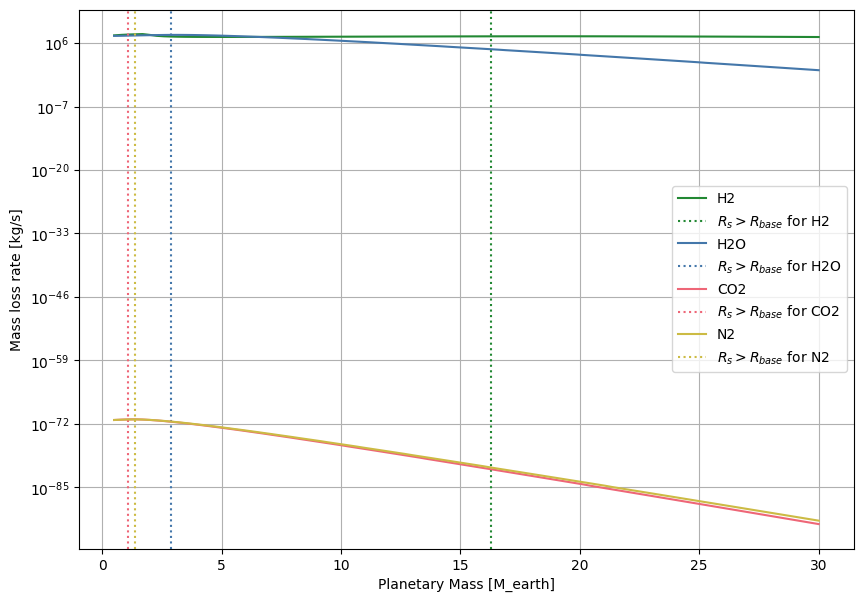

In [43]:
#I want to plot and compare how planets of different compositions


### Want to examine how planetary mass affects mass loss rate ###
M_earth = 5.9722 * 10**24               #[kg]        mass of the earth
Mass_array = np.linspace(0.5, 30, 100, endpoint=True) * M_earth #[kg] array of planetary masses from 0.5 to 30 times the mass of the earth

atms_H2_varied_mass = np.array([make_simple_atmosphere(
    M_p=M,
    R_p=2.73 * 6.371 * 10**6,
    F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
    nu_0=3.288467085473 * 10**15,
    mu_wind=0.5,
    mu_plus_wind=1.0,
    T_eq=553,
    mu_photo=2,
    P_0=2000,
    T_wind=10**4,
    dominant_species='H2'
) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 1 to 30 times the mass of the earth, where M_p: planetary mass

atms_H2O_varied_mass = np.array([make_simple_atmosphere(
    M_p=M,
    R_p=2.73 * 6.371 * 10**6,
    F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
    nu_0=4.835981008048 * 10**15,
    mu_wind=3,
    mu_plus_wind=6,
    T_eq=553,
    mu_photo=18,
    P_0=2000,
    T_wind=10**4,
    dominant_species='H2O'
) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 1 to 30 times the mass of the earth, where M_p: planetary mass

atms_CO2_varied_mass = np.array([make_simple_atmosphere(
    M_p=M,
    R_p=2.73 * 6.371 * 10**6,
    F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
    nu_0=3.3368 * 10**158 * 10**15,
    mu_wind=7.2,
    mu_plus_wind=14.4,
    T_eq=553,
    mu_photo=12+(16*2),
    P_0=2000,
    T_wind=10**4,
    dominant_species='CO2'
) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 1 to 30 times the mass of the earth, where M_p: planetary mass

atms_N2_varied_mass = np.array([make_simple_atmosphere(
    M_p=M,
    R_p=2.73 * 6.371 * 10**6,
    F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
    nu_0=3.7721 * 10**158 * 10**15,
    mu_wind=7,
    mu_plus_wind=14,
    T_eq=553,
    mu_photo=(14*2),
    P_0=2000,
    T_wind=10**4,
    dominant_species='N2'
) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 1 to 30 times the mass of the earth, where M_p: planetary mass

atmospheres_to_sweep = {
        'H2' : atms_H2_varied_mass,
        'H2O' : atms_H2O_varied_mass,
        'CO2' : atms_CO2_varied_mass,
        'N2' : atms_N2_varied_mass
        }

atmospheres_swept = {}

for species in atmospheres_to_sweep.keys():
    # Unpack the two values returned by the fixed function
    rates, r_break = sweep_masses(atmospheres_to_sweep[species])
    atmospheres_swept[species] = (rates, r_break)

# Now your plotting code will work:
# ax.plot(masses, atmospheres_swept[keys[0]], ...)
keys = list(atmospheres_swept.keys())

print(atmospheres_swept[keys[2]][0])

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle=('Mass loss rate for different masses')
masses = Mass_array / M_earth
ax.plot(masses, atmospheres_swept[keys[0]][0], label=keys[0], color='#228833')
ax.axvline(masses[atmospheres_swept[keys[0]][1]], label=f'$R_s > R_{{base}}$ for {keys[0]}', color='#228833', linestyle='dotted')
ax.plot(masses, atmospheres_swept[keys[1]][0], label=keys[1], color='#4477AA')
ax.axvline(masses[atmospheres_swept[keys[1]][1]], label=f'$R_s > R_{{base}}$ for {keys[1]}', color='#4477AA', linestyle='dotted')
ax.plot(masses, atmospheres_swept[keys[2]][0], label=keys[2], color='#EE6677')
ax.axvline(masses[atmospheres_swept[keys[2]][1]], label=f'$R_s > R_{{base}}$ for {keys[2]}',  color='#EE6677', linestyle='dotted')
ax.plot(masses, atmospheres_swept[keys[3]][0], label=keys[3], color='#CCBB44')
ax.axvline(masses[atmospheres_swept[keys[3]][1]], label=f'$R_s > R_{{base}}$ for {keys[3]}', color='#CCBB44', linestyle='dotted')
ax.legend()
ax.grid(True)
ax.set_xlabel('Planetary Mass [M_earth]')
ax.set_ylabel('Mass loss rate [kg/s]')
ax.semilogy()
plt.show()


R_s 6e+05 < 5.4e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 6.4e+05 < 5.4e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 6.7e+05 < 5.5e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 7.1e+05 < 5.6e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 7.5e+05 < 4.9e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 7.8e+05 < 4e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 8.2e+05 < 3.4e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 8.5e+05 < 3e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 8.9e+05 < 2.7e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 9.2e+05 < 2.5e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 9.6e+05 < 2.

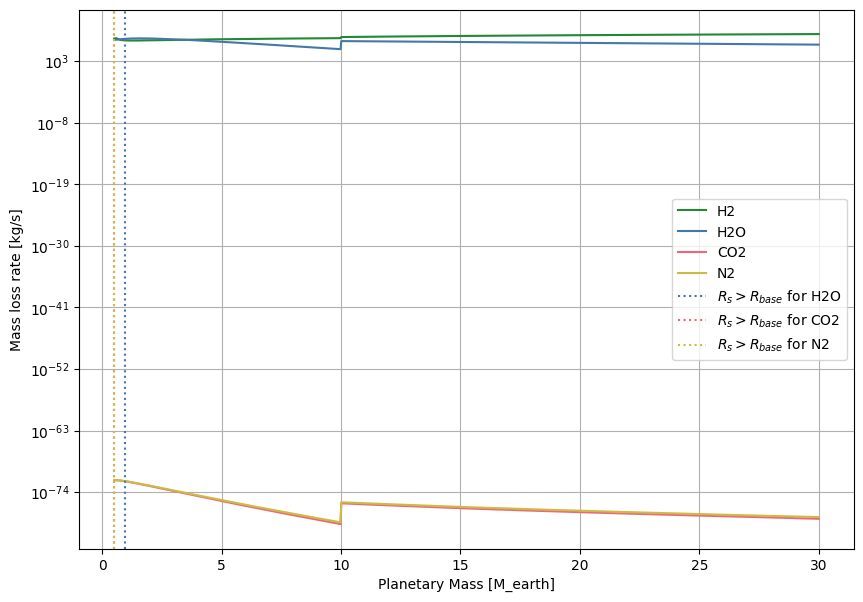

In [ ]:
#I want to compare how implementing the mass-radius relation changes the result of the mass sweep


### Want to examine how planetary mass affects mass loss rate ###
M_earth = 5.9722 * 10**24               #[kg]        mass of the earth
Mass_array = np.linspace(0.5, 30, 1000, endpoint=True) * M_earth #[kg] array of planetary masses from 0.5 to 30 times the mass of the earth

atms_H2_varied_mass = np.array([make_simple_atmosphere(
    M_p=M,
    F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
    nu_0=3.288467085473 * 10**15,
    mu_wind=0.5,
    mu_plus_wind=1.0,
    T_eq=553,
    mu_photo=2,
    P_0=2000,
    T_wind=10**4,
    dominant_species='H2',
    determine_radius=True
) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 0.5 to 30 times the mass of the earth, where M_p: planetary mass


atms_H2O_varied_mass = np.array([make_simple_atmosphere(
    M_p=M,
    F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
    nu_0=4.835981008048 * 10**15,
    mu_wind=3,
    mu_plus_wind=6,
    T_eq=553,
    mu_photo=18,
    P_0=2000,
    T_wind=10**4,
    dominant_species='H2O',
    determine_radius=True
) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 0.5 to 30 times the mass of the earth, where M_p: planetary mass

atms_CO2_varied_mass = np.array([make_simple_atmosphere(
    M_p=M,
    F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
    nu_0=3.3368 * 10**158 * 10**15,
    mu_wind=7.2,
    mu_plus_wind=14.4,
    T_eq=553,
    mu_photo=12+(16*2),
    P_0=2000,
    T_wind=10**4,
    dominant_species='CO2',
    determine_radius=True
) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 0.5 to 30 times the mass of the earth, where M_p: planetary mass

atms_N2_varied_mass = np.array([make_simple_atmosphere(
    M_p=M,
    F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
    nu_0=3.7721 * 10**158 * 10**15,
    mu_wind=7,
    mu_plus_wind=14,
    T_eq=553,
    mu_photo=(14*2),
    P_0=2000,
    T_wind=10**4,
    dominant_species='N2',
    determine_radius=True
) for M in Mass_array]) #[Atmosphere] array of Atmosphere objects with different planetary masses from 0.5 to 30 times the mass of the earth, where M_p: planetary mass

atmospheres_to_sweep_mass = {
        'H2' : atms_H2_varied_mass,
        'H2O' : atms_H2O_varied_mass,
        'CO2' : atms_CO2_varied_mass,
        'N2' : atms_N2_varied_mass
        }

atmospheres_swept_mass = {}

for species in atmospheres_to_sweep_mass.keys():
    # Unpack the two values returned by the fixed function
    rates, r_break = sweep_masses(atmospheres_to_sweep_mass[species])
    atmospheres_swept_mass[species] = (rates, r_break)


keys = list(atmospheres_swept_mass.keys())

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle=('Mass loss rate for different masses')
masses = Mass_array / M_earth

ax.plot(masses, atmospheres_swept_mass[keys[0]][0], label=keys[0], color='#228833')
ax.plot(masses, atmospheres_swept_mass[keys[1]][0], label=keys[1], color='#4477AA')
ax.plot(masses, atmospheres_swept_mass[keys[2]][0], label=keys[2], color='#EE6677')
ax.plot(masses, atmospheres_swept_mass[keys[3]][0], label=keys[3], color='#CCBB44')
colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
for i, ele in enumerate(keys):
    regime_break_index = atmospheres_swept_mass[keys[i]][1]
    if regime_break_index is not None:
        ax.axvline(masses[atmospheres_swept_mass[keys[i]][1]], label=f'$R_s > R_{{base}}$ for {keys[i]}', color=colours[i], linestyle='dotted')

ax.legend()
ax.grid(True)
ax.set_xlabel('Planetary Mass [M_earth]')
ax.set_ylabel('Mass loss rate [kg/s]')
ax.semilogy()
plt.show()
plt.close(fig)




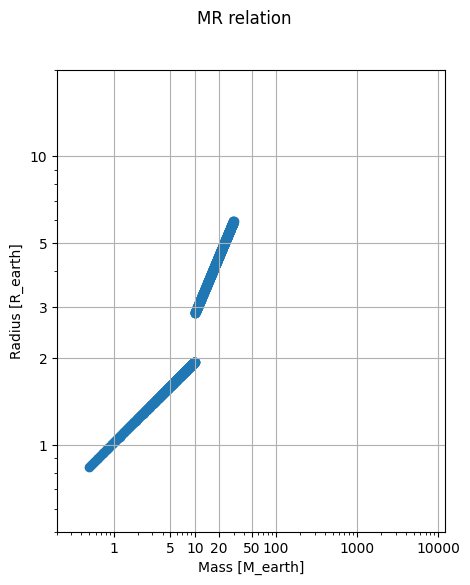

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(5,6))
fig.suptitle('MR relation')
R_earth = 6371000 #mean earth radius
radii = np.array([Atmosphere.determine_radius_from_MR_relation(m)/R_earth for m in Mass_array])
ax.scatter(masses, radii)
# 3. Switch BOTH axes to log scales
ax.set_xscale('log')
ax.set_yscale('log')

# 4. Define and force the exact tick marks seen in the paper
x_ticks = [1, 5, 10, 20, 50, 100, 1000, 10000]
ax.set_xticks(x_ticks, labels=[str(x) for x in x_ticks])

y_ticks = [1, 2, 3, 5, 10]
ax.set_yticks(y_ticks, labels=[str(y) for y in y_ticks])

# 5. Set limits to frame the data like the paper's plot bounds
ax.set_xlim(0.2, 12000)
ax.set_ylim(0.5, 20)
ax.set_xlabel('Mass [M_earth]')
ax.set_ylabel('Radius [R_earth]')
ax.grid()
plt.show()
plt.close(fig)

In [ ]:
### Want to see how the gravitational well changes with the MR relation ###

### compare with salz et al 2016 if can host hydrodynamic escape ###
G = sp.constants.G #[m^3 kg^-1 s^-2]

grav_pot_SI = np.array([- G * m / Atmosphere.determine_radius_from_MR_relation(m) for m in Mass_array]) #[m^2 s^-2] gravitational potential at the planetary radius, where G: gravitational constant, M_p: planetary mass, R_p: planetary radius
grav_pot_cgs = grav_pot_SI * cm_to_m**(-2) #[cm^2 s^-2] gravitational potential at the planetary radius in cgs units, where grav_pot_SI: gravitational potential at the planetary radius in SI units
grav_compare = np.log10(-grav_pot_cgs) #[log10(cm^2 s^-2)] logarithm of the negative gravitational potential at the planetary radius in cgs units, where grav_pot_cgs: gravitational potential at the planetary radius in cgs units
salz_strong_grav_threshold = 13.6 #Larger than this value and gravity is too high for hydrodynamic escape. No EL and no wind for RR. REFERENCE Salz et. al. 2016
salz_weak_grav_threshold = 13.11 #Smaller than this value and the planet can host hydrodynamic wind and therefore EL and RR.


if grav_compare < salz_weak_grav_threshold:
    print(f"Planet can host hydrodynamic escape through wind: {grav_compare} < {salz_weak_grav_threshold} (log10(grav pot [cm^2 s^-2])")
elif grav_compare > salz_strong_grav_threshold:
    print(f"Planet cannot host hydrodynamic escape through wind: {grav_compare} > {salz_strong_grav_threshold} (log10(grav pot [cm^2 s^-2])")
else: #the gravitational potential is in between
    print(f"Planet is in intermediate regime of gravitationally binding atmosphere, wind strength declines rapidly")

fig, ax = plt.subplots(1, 1, (6, 8))
fig.suptitle('Gravitational well of MR relation')
ax.scatter(masses)
ax.set_xscale('log')
ax.set_yscale('log')

NameError: name 'sp' is not defined

R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, escape is not radiation-recombination-limited. Setting R_s = R_base.
R_s 1e+07 < 2.2e+07 R_base, es

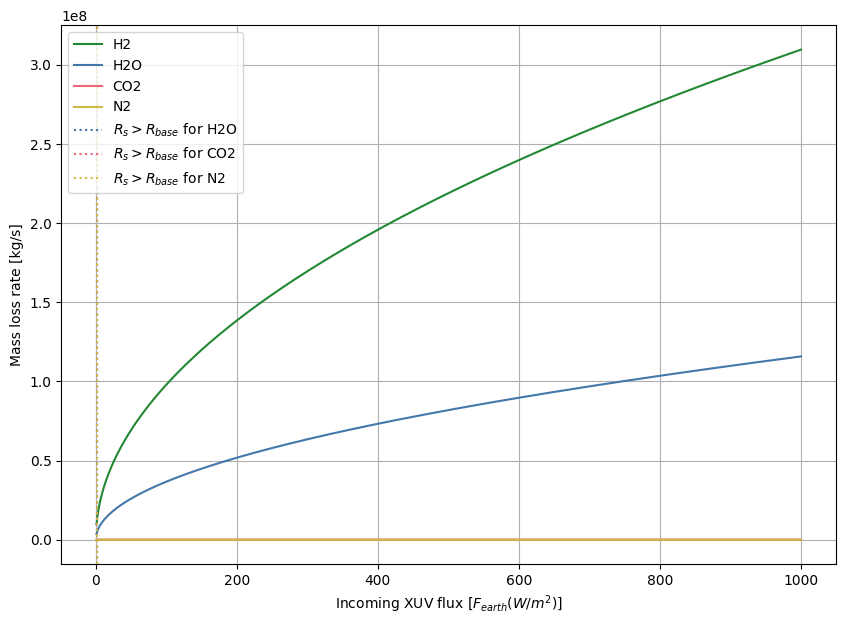

In [ ]:
#I want to plot and compare how planets of different incoming xuv fluxes are impacted on their mass loss rates

### Want to examine how different fluxes affects mass loss rate ###
F_xuv_earth_1 = 0.2196388835              #[W m^-2]        xuv flux of the earth
flux_array = np.linspace(1, 1000, 5000, endpoint=True) * F_xuv_earth_1 #[kg] array of planetary masses from 0.5 to 30 times the mass of the earth

atms_H2_varied_flux = np.array([make_simple_atmosphere(
    M_p=8.41 * 5.9722 * 10**24,
    R_p=2.73 * 6.371 * 10**6,
    F_xuv=F,
    nu_0=3.288467085473 * 10**15,
    mu_wind=0.5,
    mu_plus_wind=1.0,
    T_eq=553,
    mu_photo=2,
    P_0=2000,
    T_wind=10**4,
    dominant_species='H2'
) for F in flux_array]) #[Atmosphere] array of Atmosphere objects with different incoming xuv fluxes

atms_H2O_varied_flux = np.array([make_simple_atmosphere(
    M_p=8.41 * 5.9722 * 10**24,
    R_p=2.73 * 6.371 * 10**6,
    F_xuv=F,
    nu_0=4.835981008048 * 10**15,
    mu_wind=3,
    mu_plus_wind=6,
    T_eq=553,
    mu_photo=18,
    P_0=2000,
    T_wind=10**4,
    dominant_species='H2O'
) for F in flux_array])

atms_CO2_varied_flux = np.array([make_simple_atmosphere(
    M_p=8.41 * 5.9722 * 10**24,
    R_p=2.73 * 6.371 * 10**6,
    F_xuv=F,
    nu_0=3.3368 * 10**158 * 10**15,
    mu_wind=7.2,
    mu_plus_wind=14.4,
    T_eq=553,
    mu_photo=12+(16*2),
    P_0=2000,
    T_wind=10**4,
    dominant_species='CO2'
) for F in flux_array]) 

atms_N2_varied_flux = np.array([make_simple_atmosphere(
    M_p=8.41 * 5.9722 * 10**24,
    R_p=2.73 * 6.371 * 10**6,
    F_xuv=F,
    nu_0=3.7721 * 10**158 * 10**15,
    mu_wind=7,
    mu_plus_wind=14,
    T_eq=553,
    mu_photo=(14*2),
    P_0=2000,
    T_wind=10**4,
    dominant_species='N2'
) for F in flux_array]) 

atmospheres_to_sweep_flux = {
        'H2' : atms_H2_varied_flux,
        'H2O' : atms_H2O_varied_flux,
        'CO2' : atms_CO2_varied_flux,
        'N2' : atms_N2_varied_flux
        }

atmospheres_swept_flux = {}

for species in atmospheres_to_sweep_flux.keys():
    # Unpack the two values returned by the fixed function
    rates, r_break = sweep_masses(atmospheres_to_sweep_flux[species])
    atmospheres_swept_flux[species] = (rates, r_break)

keys = list(atmospheres_swept_flux.keys())

print(atmospheres_swept_flux[keys[0]][1])

colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle=('Mass loss rate for different incoming XUV fluxes')
fluxes = flux_array / F_xuv_earth_1
ax.plot(fluxes, atmospheres_swept_flux[keys[0]][0], label=keys[0], color=colours[0])
ax.plot(fluxes, atmospheres_swept_flux[keys[1]][0], label=keys[1], color=colours[1])
ax.plot(fluxes, atmospheres_swept_flux[keys[2]][0], label=keys[2], color=colours[2])
ax.plot(fluxes, atmospheres_swept_flux[keys[3]][0], label=keys[3], color=colours[3])

for i, ele in enumerate(keys):
    regime_break_index = atmospheres_swept_flux[keys[i]][1]
    if regime_break_index is not None:
        ax.axvline(fluxes[atmospheres_swept_flux[keys[i]][1]], label=f'$R_s > R_{{base}}$ for {keys[i]}', color=colours[i], linestyle='dotted')

ax.legend()
ax.grid(True)
ax.set_xlabel('Incoming XUV flux $[F_{earth} (W/m^2)]$')
ax.set_ylabel('Mass loss rate [kg/s]')
plt.show()
